Event management companies generate large amounts of structured and unstructured business data across event records, vendor information, revenue reports, operational documents, and business policies. However, this information is often scattered across Excel files and PDF documents, making it difficult for business teams to quickly find information, analyze performance, and make data-driven decisions.

The objective of this project is to build an AI Analyst powered by RAG and SQL that can understand natural-language business questions, retrieve relevant information from PDF documents, query structured event data, and combine both sources to generate accurate, contextual, and actionable business insights.

Key challenges addressed
* Scattered data — Information exists across Excel and PDF files.
* Manual analysis — Business users need to manually search documents and analyze spreadsheets.
* Complex queries — Users may not know SQL or where the required information is stored.
* Disconnected information — Numerical data and business context are stored separately.
* Risk of unsupported answers — Traditional LLMs may generate answers without grounding them in company data.
* Slow decision-making — Analysts spend time collecting information instead of generating insights.

In [2]:
!pip install -q -U \
    langchain \
    langchain-community \
    langchain-text-splitters \
    langchain-huggingface \
    langchain-groq \
    faiss-cpu \
    sentence-transformers \
    pypdf \
    openpyxl \
    sqlalchemy \
    gradio

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


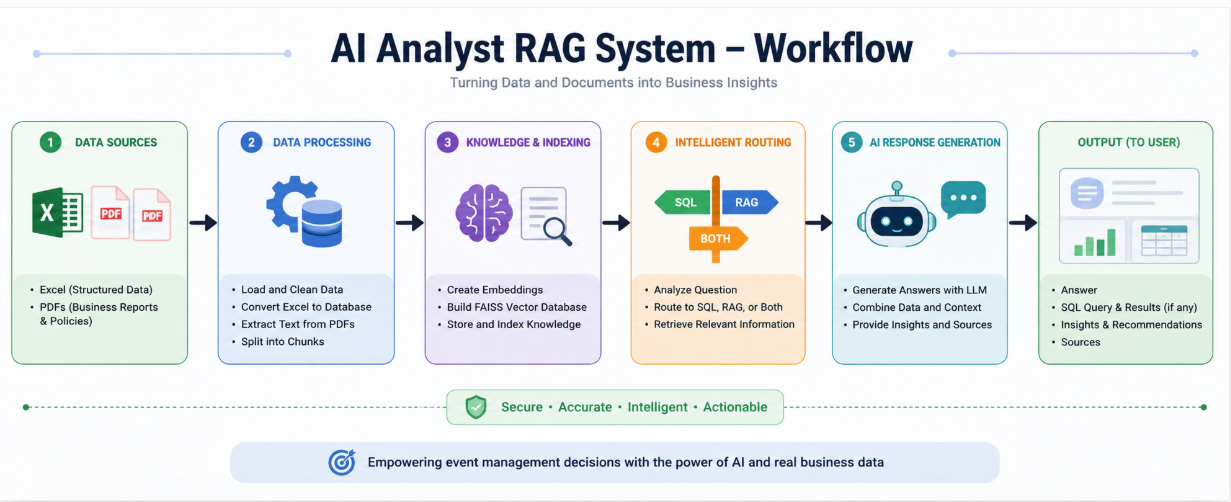

In [3]:
import os
import sqlite3
import pandas as pd

from pathlib import Path


from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

from langchain_groq import ChatGroq

import gradio as gr

from IPython.display import display, Markdown

print("Libraries imported successfully!")

C:\Users\manis\AppData\Local\Temp\ipykernel_1008\4103701362.py:8: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


Libraries imported successfully!


In [4]:
# Load files directly from local working directory
import os

print("Loaded local files from current directory:")
for f in os.listdir('.'):
    if f.endswith(('.xlsx', '.pdf')):
        print(" -", f)


Loaded local files from current directory:
 - Event_Management_AI_Analyst_Data.xlsx
 - Event_Management_Business_Reports.pdf
 - Event_Management_Operations_Playbook.pdf


In [5]:
import os

print("Files uploaded:\n")

for file in os.listdir():
    print(file)

Files uploaded:

.env.example
.git
.gitignore
.streamlit
AI Analyst.ipynb
event_management.db
Event_Management_AI_Analyst_Data.xlsx
Event_Management_Business_Reports.pdf
Event_Management_Operations_Playbook.pdf
README.md
src
streamlit_app.py


In [6]:
EXCEL_FILE = "Event_Management_AI_Analyst_Data.xlsx"

BUSINESS_REPORT = "Event_Management_Business_Reports.pdf"

OPERATIONS_REPORT = "Event_Management_Operations_Playbook.pdf"

print("Excel:", os.path.exists(EXCEL_FILE))
print("Business Report:", os.path.exists(BUSINESS_REPORT))
print("Operations Report:", os.path.exists(OPERATIONS_REPORT))

Excel: True
Business Report: True
Operations Report: True


In [7]:
events_df = pd.read_excel(
    EXCEL_FILE,
    sheet_name="Events"
)

vendors_df = pd.read_excel(
    EXCEL_FILE,
    sheet_name="Vendors"
)

monthly_df = pd.read_excel(
    EXCEL_FILE,
    sheet_name="Monthly_Summary"
)

In [9]:
print("EVENTS")
display(events_df.head())

EVENTS


,Event_ID,City,Event_Type,Event_Name,Event_Date,Client,Revenue_INR,Attendees,Satisfaction_Pct,Lead_Conversion_Pct
0,EVT001,Mumbai,Corporate,Annual Leadership Summit,2026-01-18,TechNova India,1850000,420,78,55
1,EVT002,Pune,Wedding,Royal Maharashtrian Wedding,2026-01-25,Private Client,1250000,650,91,72
2,EVT003,Bengaluru,Corporate,Product Launch 2026,2026-02-07,FinEdge Technologies,2100000,380,84,61
3,EVT004,Delhi,Exhibition,India Mobility Expo Booth,2026-02-15,AutoSphere Pvt Ltd,2750000,1200,76,48
4,EVT005,Hyderabad,Conference,Healthcare Innovation Forum,2026-02-28,MedCore India,1650000,500,88,66


In [10]:
print("VENDORS")
display(vendors_df.head())

VENDORS


,Vendor_ID,Vendor_Name,Category,Base_City,Rating,Events_Handled,On_Time_Pct
0,VEN001,Royal Catering Co.,Catering,Mumbai,4.7,185,96
1,VEN002,PixelCraft Studios,Photography,Pune,4.5,142,91
2,VEN003,StagePro India,Production,Bengaluru,4.6,210,94
3,VEN004,Jaipur Decor House,Decor,Jaipur,4.8,176,97
4,VEN005,Goa Sound & Light,AV & Sound,Goa,4.3,128,88


In [11]:
print("MONTHLY SUMMARY")
display(monthly_df.head())

MONTHLY SUMMARY


,Month,Events,Revenue_INR,Avg_Satisfaction_Pct,Avg_Lead_Conversion_Pct
0,Jan,2,3100000,84.500000,63.500000
1,Feb,3,6500000,82.666667,58.333333
2,Mar,2,2430000,93.000000,77.500000
3,Apr,2,5500000,89.000000,74.000000
4,May,2,3300000,88.000000,70.500000


In [12]:
print("Events:", events_df.shape)
print("Vendors:", vendors_df.shape)
print("Monthly:", monthly_df.shape)

Events: (24, 10)
Vendors: (8, 7)
Monthly: (12, 5)


In [13]:
print("\nEvents columns:")
print(events_df.columns.tolist())

print("\nVendor columns:")
print(vendors_df.columns.tolist())

print("\nMonthly columns:")
print(monthly_df.columns.tolist())


Events columns:
['Event_ID', 'City', 'Event_Type', 'Event_Name', 'Event_Date', 'Client', 'Revenue_INR', 'Attendees', 'Satisfaction_Pct', 'Lead_Conversion_Pct']

Vendor columns:
['Vendor_ID', 'Vendor_Name', 'Category', 'Base_City', 'Rating', 'Events_Handled', 'On_Time_Pct']

Monthly columns:
['Month', 'Events', 'Revenue_INR', 'Avg_Satisfaction_Pct', 'Avg_Lead_Conversion_Pct']


In [14]:
DB_PATH = "event_management.db"

print("Database path:", DB_PATH)

Database path: event_management.db


In [15]:
import sqlite3

conn = sqlite3.connect(DB_PATH)

events_df.to_sql(
    "events",
    conn,
    if_exists="replace",
    index=False
)

vendors_df.to_sql(
    "vendors",
    conn,
    if_exists="replace",
    index=False
)

monthly_df.to_sql(
    "monthly_summary",
    conn,
    if_exists="replace",
    index=False
)


print("SQLite database created successfully.")

SQLite database created successfully.


In [16]:
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type='table';
    """,
    conn
)

display(tables)

,name
0,events
1,vendors
2,monthly_summary


In [17]:
query = """
SELECT
    City,
    SUM(Revenue_INR) AS Total_Revenue
FROM events
GROUP BY City
ORDER BY Total_Revenue DESC;
"""

result = pd.read_sql_query(
    query,
    conn
)

display(result)

,City,Total_Revenue
0,Jaipur,9000000
1,Mumbai,8780000
2,Delhi,7400000
3,Bengaluru,6250000
4,Pune,5650000
5,Goa,5620000
6,Hyderabad,5250000
7,Chennai,1350000


###RAG Pipeline

In [18]:
pdf_files = [
    BUSINESS_REPORT,
    OPERATIONS_REPORT
]

all_documents = []

for pdf_file in pdf_files:

    loader = PyPDFLoader(
        pdf_file
    )

    docs = loader.load()

    all_documents.extend(docs)

print(
    "Total pages loaded:",
    len(all_documents)
)

Total pages loaded: 2


In [19]:
print(
    all_documents[1].page_content[:2000]
)

Event Management — Operations & Strategy Playbook
Service Strategy
For corporate events, prioritize reliable production, AV, registration and conference logistics. For weddings,
prioritize decor, catering, hospitality, photography and destination coordination. For exhibitions, prioritize booth
execution, visitor flow, production timelines and vendor reliability.
City Strategy
Mumbai is a strong corporate and wedding market with high event frequency. Bengaluru is attractive for
technology-sector conferences and corporate launches. Jaipur and Goa are strategic destination-wedding
markets. Delhi and Hyderabad provide opportunities for exhibitions, conferences and corporate events.
Vendor Management Rules
Prefer vendors with ratings above 4.5 and on-time performance above 92% for high-value events. For large
exhibitions, maintain backup production and AV vendors. Destination events should have local vendor
alternatives to reduce logistics risk.
Risk Indicators
Flag events where satisfactio

### Chunking

In [20]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=150
)

chunks = text_splitter.split_documents(
    all_documents
)

print(
    "Total chunks:",
    len(chunks)
)

Total chunks: 6


In [21]:
print(chunks[0].page_content)

print("\nMetadata:")
print(chunks[2].metadata)

Event Management Company — Business Reports
Company Overview
UtsavSphere Events India is a fictional pan-India event management company serving corporate events,
weddings, conferences and exhibitions. The company operates across Mumbai, Pune, Bengaluru, Delhi,
Hyderabad, Goa and Jaipur.
Q1–Q3 Business Highlights
Corporate and wedding events generated the strongest revenue contribution. Destination weddings in Jaipur
and Goa achieved the highest satisfaction scores. Mumbai and Bengaluru remained important corporate-event
markets. Exhibition events generated high absolute revenue but generally showed lower satisfaction and
lead-conversion rates than weddings.
Key Business Observations
Destination weddings had satisfaction scores above 95% in most cases, but they also required higher event

Metadata:
{'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-08-07T21:29:40+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-08-07T2

### Embedding

In [22]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

print("Embedding model loaded.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\manis\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\manis\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded.


### VectorDB

In [23]:
vector_db = FAISS.from_documents(
    chunks,
    embeddings
)

print("FAISS vector database created.")

FAISS vector database created.


In [24]:
vector_db.save_local(
    "event_management_faiss"
)

print("FAISS database saved.")

FAISS database saved.


In [25]:
question = "What are the vendor selection criteria?"

retrieved_docs = vector_db.similarity_search(
    question,
    k=3
)

for i, doc in enumerate(retrieved_docs):

    print(
        f"\n========== RESULT {i+1} =========="
    )

    print(
        doc.page_content
    )

    print(
        "\nSOURCE:",
        doc.metadata
    )


========== RESULT 1 ==========
markets. Delhi and Hyderabad provide opportunities for exhibitions, conferences and corporate events.
Vendor Management Rules
Prefer vendors with ratings above 4.5 and on-time performance above 92% for high-value events. For large
exhibitions, maintain backup production and AV vendors. Destination events should have local vendor
alternatives to reduce logistics risk.
Risk Indicators
Flag events where satisfaction is below 85%, lead conversion is below 60%, or revenue is high but operational
performance is weak. Such events should be reviewed for staffing, vendor quality, budget allocation, client
expectation management and event complexity.
Recommended AI Analyst Outputs
For analytical questions, provide the direct answer, supporting numbers, key drivers, business implications,

SOURCE: {'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-08-07T21:29:40+00:00', 'author': '(anonymous)', 'keywords': '', 'mo

In [ ]:
import os
from getpass import getpass

# Load API key from environment variable or prompt user securely
if "GROQ_API_KEY" not in os.environ or not os.environ["GROQ_API_KEY"]:
    os.environ["GROQ_API_KEY"] = getpass("Enter your Groq API Key: ")

print("Groq API key configured successfully.")


Groq API key configured successfully.


In [31]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

print("Groq LLM loaded.")

Groq LLM loaded.


In [32]:
response = llm.invoke(
    "Explain LLM in one sentence."
)

print(response.content)

AuthenticationError: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'invalid_api_key'}}

In [ ]:
def retrieve_documents(
    question,
    k=4
):

    docs = vector_db.similarity_search(
        question,
        k=k
    )

    return docs

In [ ]:
def create_context(docs):

    context_parts = []

    for doc in docs:

        source = Path(
            doc.metadata.get(
                "source",
                "Unknown"
            )
        ).name

        page = (
            doc.metadata.get(
                "page",
                0
            ) + 1
        )

        context_parts.append(
            f"""
SOURCE: {source}
PAGE: {page}

CONTENT:
{doc.page_content}
"""
        )

    return "\n\n".join(
        context_parts
    )

In [ ]:
def rag_answer(question):

    docs = retrieve_documents(
        question,
        k=4
    )

    context = create_context(
        docs
    )

    prompt = f"""
You are an expert AI Business Analyst
for an Indian event management company.

Answer the user's question using ONLY
the provided business documents.

IMPORTANT RULES:

1. Do not invent facts.
2. Do not invent numbers.
3. Do not use outside knowledge.
4. If information is unavailable,
   clearly say so.
5. Provide useful business insights.

Return:

## Answer

## Key Insights

## Business Implications

## Sources

KNOWLEDGE BASE:

{context}

USER QUESTION:

{question}
"""

    response = llm.invoke(
        prompt
    )

    return response.content, docs

In [ ]:
answer, docs = rag_answer(
    "What are the vendor selection criteria?"
)

print(answer)

## Answer
The vendor selection criteria are based on ratings and on-time performance. Vendors with ratings above 4.5 and on-time performance above 92% are preferred for high-value events.

## Key Insights
The company prioritizes vendor reliability, especially for high-value events, to ensure successful event execution. The use of backup production and AV vendors for large exhibitions and local vendor alternatives for destination events also highlights the importance of vendor selection in risk management.

## Business Implications
The vendor selection criteria can impact the overall quality and success of events, directly affecting client satisfaction and revenue. By prioritizing vendors with high ratings and on-time performance, the company can mitigate risks and enhance its reputation in the market.

## Sources
- Event_Management_Operations_Playbook.pdf, Page 1: "Prefer vendors with ratings above 4.5 and on-time performance above 92% for high-value events."


In [ ]:
answer, docs = rag_answer(
    "How was the performance in Q1?"
)

print(answer)


## Answer
The provided business documents do not specifically mention the performance of the company in Q1 alone. However, they do provide information on the business highlights for Q1-Q3.

## Key Insights
The company's business highlights for Q1-Q3 show that corporate and wedding events generated the strongest revenue contribution. Destination weddings in Jaipur and Goa achieved the highest satisfaction scores. Mumbai and Bengaluru remained important corporate-event markets.

## Business Implications
While the exact performance in Q1 is not available, the Q1-Q3 business highlights suggest that the company had a strong revenue contribution from corporate and wedding events during this period.

## Sources
- Event_Management_Business_Reports.pdf, PAGE: 1
- Event_Management_Business_Reports.pdf, PAGE: 1 (second mention)


In [ ]:
def format_sources(docs):

    sources = []

    for doc in docs:

        source = Path(
            doc.metadata.get(
                "source",
                "Unknown"
            )
        ).name

        page = (
            doc.metadata.get(
                "page",
                0
            ) + 1
        )

        source_text = (
            f"📄 **{source}** — "
            f"Page {page}"
        )

        if source_text not in sources:

            sources.append(
                source_text
            )

    return "\n\n".join(
        sources
    )

In [ ]:
print(
    format_sources(docs)
)

📄 **Event_Management_Business_Reports.pdf** — Page 1

📄 **Event_Management_Operations_Playbook.pdf** — Page 1


In [ ]:
def execute_sql(query):

    try:

        # Create a new connection for every query
        connection = sqlite3.connect(
            DB_PATH
        )

        result = pd.read_sql_query(
            query,
            connection
        )

        connection.close()

        return result

    except Exception as e:

        return f"SQL Error: {str(e)}"

In [ ]:
DATABASE_SCHEMA = """

TABLE: events

Columns:
Event_ID
City
Event_Type
Event_Name
Event_Date
Client
Revenue_INR
Attendees
Satisfaction_Pct
Lead_Conversion_Pct


TABLE: vendors

Columns:
Vendor_ID
Vendor_Name
Category
Base_City
Rating
Events_Handled
On_Time_Pct


TABLE: monthly_summary

Columns:
Month
Events
Revenue_INR
Avg_Satisfaction_Pct
Avg_Lead_Conversion_Pct

"""

In [ ]:
def generate_sql(question):

    prompt = f"""
You are an expert SQLite data analyst.

DATABASE SCHEMA:

{DATABASE_SCHEMA}

Generate ONLY a valid SQLite SQL query
to answer the user's question.

RULES:

- Return only SQL.
- No markdown.
- No explanation.
- Use only the provided tables.
- Use only the provided columns.
- Do not invent columns.
- Use SUM for total revenue.
- Use AVG for averages.
- Use COUNT for counting.
- Use GROUP BY for comparisons.
- Use ORDER BY for rankings.

USER QUESTION:

{question}
"""

    response = llm.invoke(
        prompt
    )

    sql = response.content.strip()

    sql = sql.replace(
        "```sql",
        ""
    )

    sql = sql.replace(
        "```",
        ""
    )

    return sql.strip()

In [ ]:
question = (
    "Which city generated the highest revenue?"
)

sql = generate_sql(
    question
)

print(sql)

SELECT City, SUM(Revenue_INR) AS Total_Revenue FROM events GROUP BY City ORDER BY Total_Revenue DESC LIMIT 1


In [ ]:
result = execute_sql(
    sql
)

display(result)

,City,Total_Revenue
0,Jaipur,9000000


In [ ]:
def sql_answer(question):

    sql = generate_sql(
        question
    )

    result = execute_sql(
        sql
    )

    if isinstance(
        result,
        str
    ):

        return (
            result,
            sql,
            None
        )

    result_text = result.to_string(
        index=False
    )

    prompt = f"""
You are a senior Business Analyst.

Answer the user's question using
ONLY the SQL result.

QUESTION:

{question}

SQL:

{sql}

RESULT:

{result_text}

Return:

## Answer

## Key Insights

## Business Implication

RULES:

- Do not invent numbers.
- Use only the result.
"""

    response = llm.invoke(
        prompt
    )

    return (
        response.content,
        sql,
        result
    )

In [ ]:
answer, sql, result = sql_answer(
    "Which city generated the highest revenue?"
)

print(answer)

print("\nSQL:")
print(sql)

print("\nDATA:")
display(result)

## Answer
Jaipur

## Key Insights
The city of Jaipur generated the highest revenue.

## Business Implication
Jaipur is the top revenue-generating city with a total revenue of 9000000.

SQL:
SELECT City, SUM(Revenue_INR) AS Total_Revenue FROM events GROUP BY City ORDER BY Total_Revenue DESC LIMIT 1

DATA:


,City,Total_Revenue
0,Jaipur,9000000


In [ ]:
def classify_question(question):

    prompt = f"""
You are a routing system for an AI Business Analyst.

Classify the question into exactly one:

RAG
SQL
BOTH

RAG:

Use RAG for questions about:

- company information
- business policies
- operational procedures
- vendor rules
- strategy
- qualitative knowledge

SQL:

Use SQL for questions about:

- revenue
- attendees
- counts
- averages
- rankings
- satisfaction
- lead conversion
- vendor metrics

BOTH:

Use BOTH when the question needs:

1. Numerical business data
AND
2. Business knowledge/context

QUESTION:

{question}

Return ONLY:

RAG

SQL

or

BOTH
"""

    response = llm.invoke(
        prompt
    )

    category = (
        response.content
        .strip()
        .upper()
    )

    if "BOTH" in category:

        return "BOTH"

    elif "SQL" in category:

        return "SQL"

    else:

        return "RAG"

In [ ]:
test_questions = [

    "What are the vendor selection criteria?",

    "Which city generated the highest revenue?",

    """
    Which event type generates the most revenue and what strategy should management use?
    """
]

for q in test_questions:

    print(
        f"\nQuestion: {q}"
    )

    print(
        "Route:",
        classify_question(q)
    )


Question: What are the vendor selection criteria?
Route: RAG

Question: Which city generated the highest revenue?
Route: SQL

Question: 
    Which event type generates the most revenue and what strategy should management use?
    
Route: BOTH


In [ ]:
def analyst_ui(question):

    if not question or not question.strip():

        return (
            "⚠️ Please enter a question.",
            "",
            "",
            None,
            ""
        )

    try:

        result = ai_analyst(
            question
        )

        answer = result.get(
            "answer",
            "No answer generated."
        )

        route = result.get(
            "route",
            ""
        )

        sql = result.get(
            "sql",
            ""
        )

        data = result.get(
            "result",
            None
        )

        # Make sure Gradio receives
        # a DataFrame or None
        if not isinstance(
            data,
            pd.DataFrame
        ):
            data = None

        sources = ""

        if result.get("sources"):

            sources = format_sources(
                result["sources"]
            )

        return (
            answer,
            route,
            sql,
            data,
            sources
        )

    except Exception as e:

        import traceback

        error = traceback.format_exc()

        print(error)

        return (
            f"""
## ❌ Error

text
{error}""")

In [ ]:
def ai_analyst(question):

    route = classify_question(question)

    response_dict = {
        "route": route,
        "answer": "",
        "sql": "",
        "result": None,
        "sources": []
    }

    if route == "RAG":

        answer, docs = rag_answer(question)

        response_dict["answer"] = answer

        response_dict["sources"] = docs

    elif route == "SQL":

        answer, sql, result_df = sql_answer(question)

        response_dict["answer"] = answer

        response_dict["sql"] = sql

        response_dict["result"] = result_df

    elif route == "BOTH":

        # Step 1: Get SQL query and its result

        sql_query = generate_sql(question)

        sql_result_df = execute_sql(sql_query)

        sql_result_text = ""

        if isinstance(
            sql_result_df,
            pd.DataFrame
        ):

            sql_result_text = sql_result_df.to_string(
                index=False
            )

        else:

            sql_result_text = (
                f"Error or no SQL result: "
                f"{sql_result_df}"
            )


        # Step 2: Get RAG documents

        retrieved_docs = retrieve_documents(question)

        rag_context = create_context(
            retrieved_docs
        )


        # Step 3: Combine into a single prompt for the LLM

        combined_prompt = f"""
You are an expert AI Business Analyst
for an Indian event management company.

Answer the user's question by combining information
from the provided SQL result and business documents.

IMPORTANT RULES:

1. Do not invent facts or numbers.
2. If information is unavailable, clearly say so.
3. Provide useful business insights.

Return:

## Answer
## Data-Driven Insights
## Business Context
## Business Implications
## Recommendations
## Sources

SQL QUERY:

{sql_query}

SQL RESULT:

{sql_result_text}

KNOWLEDGE BASE:

{rag_context}

USER QUESTION:

{question}
"""

        final_answer = llm.invoke(
            combined_prompt
        ).content

        response_dict["answer"] = final_answer

        response_dict["sql"] = sql_query

        response_dict["result"] = sql_result_df

        response_dict["sources"] = retrieved_docs

    return response_dict

In [ ]:
result = ai_analyst(
    "Which city generated the highest revenue?"
)

print(result["route"])
print(result["answer"])

display(result["result"])

SQL
## Answer
Jaipur

## Key Insights
The city with the highest revenue is Jaipur, with a total revenue of 9000000.

## Business Implication
Jaipur is the top-performing city in terms of revenue generation, with a total revenue of 9000000.


,City,Total_Revenue
0,Jaipur,9000000


In [ ]:
result = ai_analyst(
    "Which city generated the lowest revenue?"
)

print(
    "ROUTE:",
    result["route"]
)

print(
    result["answer"]
)

print("\nSQL:")
print(
    result["sql"]
)

print("\nDATA:")
display(
    result["result"]
)

ROUTE: SQL
## Answer
Chennai

## Key Insights
The city with the lowest revenue is Chennai, with a total revenue of 1350000.

## Business Implication
The city of Chennai generated the lowest revenue of 1350000.

SQL:
SELECT City, SUM(Revenue_INR) AS Total_Revenue FROM events GROUP BY City ORDER BY Total_Revenue ASC LIMIT 1

DATA:


,City,Total_Revenue
0,Chennai,1350000


In [ ]:
result = ai_analyst(
    """
    Which event type generates the most revenue
    and what strategy should management use
    for this event type?
    """
)

print(
    "ROUTE:",
    result["route"]
)

print(
    result["answer"]
)

ROUTE: BOTH
## Answer
The event type that generates the most revenue is Wedding, with a total revenue of 15,830,000 INR.

## Data-Driven Insights
According to the SQL result, Wedding events have the highest total revenue, indicating a significant contribution to the company's overall revenue. This is consistent with the business reports, which highlight that corporate and wedding events generated the strongest revenue contribution.

## Business Context
The company operates across multiple cities in India, including Mumbai, Pune, Bengaluru, Delhi, Hyderabad, Goa, and Jaipur. The business reports suggest that destination weddings in Jaipur and Goa achieved high satisfaction scores, while Mumbai and Bengaluru are important corporate-event markets.

## Business Implications
Given that Wedding events generate the most revenue, management should prioritize strategies that enhance the company's competitiveness in this segment. This includes focusing on decor, catering, hospitality, photograph

In [ ]:
def analyst_ui(question):

    if not question or not question.strip():

        return (
            "⚠️ Please enter a question.",
            "",
            "",
            None,
            ""
        )

    try:

        result = ai_analyst(
            question
        )

        answer = result.get(
            "answer",
            "No answer generated."
        )

        route = result.get(
            "route",
            ""
        )

        sql = result.get(
            "sql",
            ""
        )

        data = result.get(
            "result",
            None
        )

        sources = ""

        if result.get(
            "sources"
        ):

            sources = format_sources(
                result["sources"]
            )

        return (
            answer,
            route,
            sql,
            data,
            sources
        )

    except Exception as e:

        return (
            f"❌ Error: {str(e)}",
            "",
            "",
            None,
            ""
        )

In [ ]:
with gr.Blocks(
    title="AI Analyst",
    theme=gr.themes.Soft()
) as demo:

    # ==============================
    # HEADER
    # ==============================

    gr.Markdown(
        """
        # 🤖 AI Analyst

        ### RAG-Powered Event Management
        ### Intelligence Assistant

        Ask questions about:

        📊 Events & Revenue
        🏢 Vendors
        📑 Business Reports
        💡 Business Strategy
        """
    )


    # ==============================
    # QUESTION
    # ==============================

    question = gr.Textbox(

        label="Ask AI Analyst",

        placeholder=(
            "Example: Which city generated "
            "the highest revenue?"
        ),

        lines=3
    )


    # ==============================
    # BUTTONS
    # ==============================

    with gr.Row():

        ask_button = gr.Button(
            "🤖 Ask AI Analyst",
            variant="primary"
        )

        clear_button = gr.Button(
            "🗑️ Clear"
        )


    # ==============================
    # ANSWER
    # ==============================

    answer = gr.Markdown(
        label="AI Analyst Answer"
    )


    # ==============================
    # ROUTE
    # ==============================

    route = gr.Textbox(
        label="🔀 Analysis Route"
    )


    # ==============================
    # SQL
    # ==============================

    sql = gr.Code(
        label="📊 SQL Query",
        language="sql"
    )


    # ==============================
    # DATA
    # ==============================

    data = gr.Dataframe(
        label="📈 Data Used",
        interactive=False
    )


    # ==============================
    # SOURCES
    # ==============================

    sources = gr.Markdown(
        label="📚 Sources"
    )


    # ==============================
    # EXAMPLES
    # ==============================

    gr.Examples(

        examples=[

            [
                "Which city generated the highest revenue?"
            ],

            [
                "What are the vendor selection criteria?"
            ],

            [
                "Which event type has the highest satisfaction?"
            ],

            [
                """
                Which event type generates the most
                revenue and what strategy should
                management use?
                """
            ],

            [
                """
                Identify high-revenue events with
                relatively low satisfaction.
                """
            ],

            [
                """
                Give management 5 recommendations
                based on the business data.
                """
            ]

        ],

        inputs=question
    )


    # ==============================
    # ASK BUTTON
    # ==============================

    ask_button.click(

        fn=analyst_ui,

        inputs=question,

        outputs=[
            answer,
            route,
            sql,
            data,
            sources
        ]
    )


    # ==============================
    # CLEAR BUTTON
    # ==============================

    clear_button.click(

        fn=lambda: (
            "",
            "",
            "",
            "",
            None,
            ""
        ),

        inputs=[],

        outputs=[
            question,
            answer,
            route,
            sql,
            data,
            sources
        ]
    )

/tmp/ipykernel_3227/3242713941.py:1: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(


In [ ]:
demo.launch(debug=True)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://6099436cae83de1b04.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://6099436cae83de1b04.gradio.live
